# 13 · PD lifetime — a estrutura a termo da probabilidade de *default*

`yggdrasil.credit_risk.ecl` responde a uma pergunta que o modelo de escoragem não
responde. O scorecard diz **quem** é mais arriscado e **quanto** risco existe em 12 meses;
a PD *lifetime* diz **quando** esse risco se materializa ao longo da vida do contrato — e
sem isso não há ECL de estágio 2, não há SICR e não há teste de estresse plurianual.

Este tutorial é o aprofundamento do bloco de PD. Roteiro:

1. **o painel de contratos** — censura, *default* absorvente e as três formas de a idade aparecer
2. **a curva** e as suas quatro representações (e o erro que elas existem para evitar)
3. **os cinco motores**, um a um, com o que cada um assume
4. **calibrar o nível** sem mexer no formato
5. **condicionar ao ciclo** — e a diferença entre os dois modos de Vasicek
6. **escorar a carteira** respeitando idade e prazo
7. **testar** a curva contra o observado
8. **persistir e registrar**

| tutoriais irmãos | |
|---|---|
| [`12`](12_tutorial_ecl.ipynb) | a perda esperada **ponta a ponta** (PD × LGD × EAD → ECL) |
| [`14`](14_tutorial_elbe.ipynb) | **ELBE** — a perda dos contratos já em *default* |
| [`15`](15_tutorial_ccf.ipynb) | **CCF/EAD** — a conversão do limite não sacado |

> Metodologia e referências: [`docs/credit-risk/ecl.md`](../../docs/credit-risk/ecl.md).

In [1]:
# --- Bootstrap: torna o pacote `yggdrasil` importável a partir do repositório,
# sem `pip install`. Procura a raiz do repo (a pasta que contém `yggdrasil/`) por
# vários âncoras — o caminho do próprio notebook (VS Code expõe `__vsc_ipynb_file__`),
# o diretório atual, os diretórios do sys.path e, no Databricks, o caminho via
# dbutils — subindo até achá-la, e a insere no sys.path. Cobre Jupyter/VS Code
# local e Databricks; se o pacote já estiver importável, é inócuo.
import sys
from pathlib import Path

def _find_yggdrasil_root():
    _anchors = []
    for _n in ("__vsc_ipynb_file__", "__file__", "__session__"):
        _v = globals().get(_n)
        if _v:
            _anchors.append(Path(str(_v)))
    _anchors.append(Path.cwd())
    _anchors += [Path(_p) for _p in sys.path if _p not in ("", ".")]
    for _a in _anchors:
        try:
            _a = _a.resolve()
        except Exception:
            continue
        for _b in (_a, *_a.parents):
            if (_b / "yggdrasil" / "__init__.py").is_file():
                return _b
    try:  # fallback Databricks: caminho do próprio notebook
        _nbp = (dbutils.notebook.entry_point.getDbutils()  # noqa: F821
                .notebook().getContext().notebookPath().get())
        for _pref in ("/Workspace", ""):
            for _b in Path(_pref + _nbp).parents:
                if (_b / "yggdrasil" / "__init__.py").is_file():
                    return _b
    except Exception:
        pass
    return None

_ygg_root = _find_yggdrasil_root()
if _ygg_root and str(_ygg_root) not in sys.path:
    sys.path.insert(0, str(_ygg_root))

In [2]:
%matplotlib inline
import os
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")   # MLflow 3.x local (seção 8)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

---
## 1 · O painel de contratos

Todo o eixo *lifetime* parte de um painel **longo**: uma linha por contrato × safra de
observação, dizendo *quantos meses o contrato tem de vida* e *se ele quebrou naquele
período*.

Geramos uma carteira com **processo gerador conhecido** — é a única forma de checar se o
método recupera a verdade. O *hazard* verdadeiro cresce com a idade (**maturação**), e é
exatamente isso que os motores têm de enxergar.

In [3]:
def carteira_sintetica(n=1200, seed=42, meses=36):
    """Painel longo com DGP conhecido: dois produtos, rating e MATURAÇÃO.

    O hazard verdadeiro é ``base[produto] · mult[rating] · (1 + t/20)`` — cresce com a
    idade, que é o fenômeno que a curva de safra tem de recuperar. As colunas de
    rotativo (sacado/limite) aceleram perto do default, para o CCF não ficar degenerado.
    """
    rng = np.random.default_rng(seed)
    base_h = {"cartao": 0.014, "consignado": 0.004}
    mult_rating = {"A": 0.6, "B": 1.0, "C": 1.8}
    linhas = []
    for i in range(n):
        produto = "cartao" if rng.uniform() < 0.5 else "consignado"
        rating = str(rng.choice(["A", "B", "C"], p=[0.5, 0.3, 0.2]))
        origem = pd.Timestamp("2020-01-01") + pd.DateOffset(months=int(rng.integers(0, 18)))
        prazo, limite = int(rng.integers(12, 49)), float(rng.lognormal(8.5, 0.5))
        sacado = limite * float(rng.beta(2.0, 3.0))
        for t in range(meses):
            h = base_h[produto] * mult_rating[rating] * (1.0 + t / 20.0)
            quebrou = int(rng.uniform() < min(h, 0.9))
            linhas.append((f"C{i:05d}", origem + pd.DateOffset(months=t), origem, quebrou,
                           produto, rating, max(prazo - t, 0), sacado, limite))
            if quebrou:
                break
            sacado = float(np.clip(sacado * (1 + rng.normal(0.012 + 2 * h, 0.05)), 0, limite))
    return pd.DataFrame(linhas, columns=[
        "id_contrato", "dt_ref", "safra_origem", "default", "produto", "rating",
        "prazo", "sacado", "limite"])

df = carteira_sintetica()
print(f"{df['id_contrato'].nunique()} contratos, {len(df)} observações, "
      f"{int(df['default'].sum())} defaults")
df.head(3)

1200 contratos, 35424 observações, 447 defaults


,id_contrato,dt_ref,safra_origem,default,produto,rating,prazo,sacado,limite
0,C00000,2020-08-01,2020-08-01,0,consignado,A,43,3228.209967,7865.822271
1,C00000,2020-09-01,2020-08-01,0,consignado,A,42,3407.987678,7865.822271
2,C00000,2020-10-01,2020-08-01,0,consignado,A,41,3658.140995,7865.822271


In [4]:
from yggdrasil.credit_risk.ecl import ContractPanel

painel = ContractPanel(
    df,
    id_col="id_contrato", date_col="dt_ref", default_col="default",
    origin_col="safra_origem",     # a idade é DERIVADA daqui
    segment_col="produto",
    term_col="prazo",
)
painel.summary().T

,0
n_obs,35424
n_contratos,1200
n_defaults,447
taxa_default_contratos,0.3725
idade_min,0
idade_max,35
safra_min,2020-01-01 00:00:00
safra_max,2024-05-01 00:00:00
n_segmentos,2
obs_pos_default_descartadas,0


### A idade pode chegar de três formas

A idade (*months on book*) é o eixo do risco. O `ContractPanel` a aceita pronta, deriva da
safra de originação, ou — quando não há nem uma nem outra — usa a **posição na trajetória**
do próprio contrato.

In [5]:
mini = pd.DataFrame({
    "id_contrato": ["A"] * 4 + ["B"] * 3,
    "dt_ref": pd.to_datetime(["2024-01-01", "2024-02-01", "2024-03-01", "2024-04-01",
                              "2024-05-01", "2024-06-01", "2024-07-01"]),
    "safra_origem": [pd.Timestamp("2023-11-01")] * 4 + [pd.Timestamp("2024-05-01")] * 3,
    "default": [0, 0, 0, 1, 0, 0, 0],
})

print("de origin_col ....:", ContractPanel(mini, origin_col="safra_origem").df["idade"].tolist())
print("da posição .......:", ContractPanel(mini.drop(columns="safra_origem")).df["idade"].tolist())

de origin_col ....: [2, 3, 4, 5, 0, 1, 2]
da posição .......: [0, 1, 2, 3, 0, 1, 2]


### *Default* é absorvente

Depois da primeira quebra o contrato **sai** do conjunto em risco. Manter as observações
posteriores contaria a mesma quebra várias vezes e achataria a curva. O painel descarta e
**registra quantas** descartou.

In [6]:
com_recaida = pd.DataFrame({
    "id_contrato": ["A"] * 4,
    "dt_ref": pd.to_datetime(["2024-01-01", "2024-02-01", "2024-03-01", "2024-04-01"]),
    "default": [0, 1, 1, 1],          # segue marcado depois de quebrar
})
p_abs = ContractPanel(com_recaida)
print(f"linhas mantidas: {len(p_abs)} de 4 | descartadas: "
      f"{p_abs.summary().loc[0, 'obs_pos_default_descartadas']}")
print("sem o corte:", len(ContractPanel(com_recaida, drop_post_default=False)), "linhas")

linhas mantidas: 2 de 4 | descartadas: 2
sem o corte: 4 linhas


### Censura: o ponto que mais erra

Um contrato originado há 6 meses **não** é um contrato que sobreviveu 60 meses — ele
apenas ainda não foi observado até lá. Tratá-los igual subestima o risco das idades altas.

Por isso a base em risco é recontada **idade a idade**, e a tabela separa quem saiu por
*default* de quem saiu por fim de janela (`n_censurado`).

In [7]:
vida = painel.at_risk()
vida.head(6)

,n_em_risco,n_default,n_censurado,hazard
idade,,,,
0,1200,10,0,0.008333
1,1190,14,0,0.011765
2,1176,9,0,0.007653
3,1167,17,0,0.014567
4,1150,12,0,0.010435
5,1138,16,0,0.014060


In [8]:
# Cada contrato sai EXATAMENTE uma vez: por default ou por censura.
saidas = int(vida["n_default"].sum() + vida["n_censurado"].sum())
print(f"{saidas} saídas para {painel.n_contracts} contratos  ->  identidade fecha: "
      f"{saidas == painel.n_contracts}")
print(f"\nbase em risco: {vida['n_em_risco'].iloc[0]} na idade 0 "
      f"-> {vida['n_em_risco'].iloc[-1]} na idade {vida.index[-1]}")

1200 saídas para 1200 contratos  ->  identidade fecha: True

base em risco: 1200 na idade 0 -> 765 na idade 35


In [9]:
# Ponderar por exposição responde a outra pergunta: a taxa em SALDO, não em contratos.
p_pond = ContractPanel(df, origin_col="safra_origem", exposure_col="sacado")
pd.DataFrame({
    "hazard em contratos": painel.at_risk()["hazard"],
    "hazard em saldo": p_pond.at_risk(weighted=True)["hazard"],
}).head(6).round(5)

,hazard em contratos,hazard em saldo
idade,,
0,0.00833,0.00855
1,0.01176,0.01354
2,0.00765,0.00890
3,0.01457,0.01430
4,0.01043,0.01233
5,0.01406,0.01428


---
## 2 · A curva e as suas quatro representações

A maior fonte de erro em PD *lifetime* **não é o motor de estimação**: é o vocabulário. A
mesma curva é pedida de quatro formas, e cada área usa uma.

| representação | responde | onde se usa |
|---|---|---|
| **condicional** (*hazard*) | "sobreviveu até `t−1`; qual a chance de quebrar em `t`?" | é o que os motores estimam |
| **marginal** | "qual a chance de quebrar **exatamente** em `t`?" (vista de hoje) | **é o que o ECL soma** |
| **acumulada** | "qual a chance de ter quebrado **até** `t`?" | SICR, comunicação |
| **sobrevivência** | "qual a chance de **não** ter quebrado até `t`?" | curvas de vida |

`PDCurve` guarda o *hazard* (a representação canônica, a única que não depende do ponto de
partida) e entrega as outras três — e aceita ser construída a partir de **qualquer uma**.

In [10]:
from yggdrasil.credit_risk.ecl import PDCurve, constant_hazard

curva = constant_hazard(pd_12m=0.06, horizon=36)    # o caminho mais curto: só a PD de 12m
curva.to_frame().head(6)

,pd_condicional,pd_marginal,pd_acumulada,sobrevivencia
horizonte,,,,
1,0.005143,0.005143,0.005143,0.994857
2,0.005143,0.005117,0.010260,0.989740
3,0.005143,0.005090,0.015350,0.984650
4,0.005143,0.005064,0.020414,0.979586
5,0.005143,0.005038,0.025452,0.974548
6,0.005143,0.005012,0.030464,0.969536


In [11]:
# As quatro carregam a MESMA informação — a ida e a volta é exata.
construtores = {"marginal": PDCurve.from_marginal, "acumulada": PDCurve.from_cumulative,
                "sobrevivência": PDCurve.from_survival}
series = {"marginal": curva.marginal(), "acumulada": curva.cumulative(),
          "sobrevivência": curva.survival()}
for nome, ctor in construtores.items():
    print(f"{nome:14s} -> hazard idêntico: {np.allclose(ctor(series[nome]).hazard_, curva.hazard_)}")

marginal       -> hazard idêntico: True
acumulada      -> hazard idêntico: True
sobrevivência  -> hazard idêntico: True


### Por que isso importa: o erro de somar a representação errada

O ECL soma a **marginal**. Somar a condicional conta o mesmo contrato várias vezes; somar
a acumulada conta a mesma perda repetidamente. Com uma curva de PD de 12 meses de 6% em 36
meses, o erro é da ordem de **grandeza**, não de arredondamento.

In [12]:
correto = curva.marginal().sum()
pd.DataFrame([
    {"o que se soma": "marginal  (CORRETO)", "soma em 36m": correto, "erro": "—"},
    {"o que se soma": "condicional (hazard)", "soma em 36m": curva.hazard().sum(),
     "erro": f"{curva.hazard().sum() / correto - 1:+.1%}"},
    {"o que se soma": "acumulada", "soma em 36m": curva.cumulative().sum(),
     "erro": f"{curva.cumulative().sum() / correto - 1:+.1%}"},
]).round(4)

,o que se soma,soma em 36m,erro
0,marginal (CORRETO),0.1694,—
1,condicional (hazard),0.1851,+9.3%
2,acumulada,3.2284,+1805.6%


### Leituras derivadas

`forward(t0, t1)` é a PD condicional **entre horizontes** — o insumo quantitativo natural
do SICR: comparar a PD *lifetime* remanescente de hoje com a de quando o contrato foi
originado.

In [13]:
print(f"PD 12m ................. {curva.pd_12m():.4%}")
print(f"PD lifetime (36m) ...... {curva.pd_lifetime():.4%}")
print(f"PD lifetime até 24m .... {curva.pd_lifetime(24):.4%}")
print(f"PD forward (12 -> 36) .. {curva.forward(12, 36):.4%}   <- quem já sobreviveu 12 meses")
s = curva.survival()
print(f"conferindo 1 - S(36)/S(12): {1 - s.iloc[35] / s.iloc[11]:.4%}")

PD 12m ................. 6.0000%
PD lifetime (36m) ...... 16.9416%
PD lifetime até 24m .... 11.6400%
PD forward (12 -> 36) .. 11.6400%   <- quem já sobreviveu 12 meses
conferindo 1 - S(36)/S(12): 11.6400%


In [14]:
# truncate corta; extend estende repetindo o último hazard (extrapolação PLANA, registrada)
curta, longa = curva.truncate(12), curva.truncate(12).extend(24)
print("truncada:", len(curta), "| estendida:", len(longa))
print("hazard extrapolado a partir do período:", longa.meta.get("extrapolada_apos"))
print("cauda constante:", np.allclose(longa.hazard_[12:], longa.hazard_[11]))

truncada: 12 | estendida: 24
hazard extrapolado a partir do período: 12
cauda constante: True


---
## 3 · Os cinco motores

`LifetimePD(method=...)` — **uma** classe, o comportamento escolhido por argumento (o mesmo
padrão do `task_type` dos segmentadores). Todos devolvem a mesma `PDCurve`, o que torna a
comparação entre métodos uma linha de código.

### 3.1 `constant` — a linha de base

*Hazard* constante calibrado à PD de 12 meses: `h = 1 − (1 − PD₁₂)^(1/12)`. A hipótese
embutida é forte — **risco constante ao longo da vida, ou seja, sem maturação** — e é
justamente por isso que ela serve de referência: qualquer motor melhor tem de se afastar
dela na direção certa.

In [15]:
from yggdrasil.credit_risk.ecl import LifetimePD

lt_const = LifetimePD(method="constant", horizon=48).fit(painel, by="produto")
lt_const.summary().round(5)

,grupo,metodo,horizonte,pd_12m,pd_24p,pd_lifetime
0,cartao,constant,48,0.16751,0.30696,0.51970
1,consignado,constant,48,0.06897,0.13317,0.24861


### 3.2 `vintage` — a taxa marginal por idade

Conta o *hazard* de cada idade sobre a **base em risco daquela idade**. É essa recontagem
que trata a censura: contratos jovens entram nas idades baixas e simplesmente não aparecem
nas altas, em vez de contarem como sobreviventes.

In [16]:
from yggdrasil.credit_risk.ecl import vintage_curve

curva_v, tabela = vintage_curve(painel, return_table=True, min_at_risk=30)
tabela[["n_em_risco", "n_default", "n_censurado", "hazard",
        "hazard_ic_inf", "hazard_ic_sup"]].iloc[[0, 5, 12, 24, 34]].round(5)

,n_em_risco,n_default,n_censurado,hazard,hazard_ic_inf,hazard_ic_sup
idade,,,,,,
0,1200,10,0,0.00833,0.00429,0.01473
5,1138,16,0,0.01406,0.00839,0.02219
12,1059,10,0,0.00944,0.00487,0.01669
24,901,13,0,0.01443,0.00811,0.02385
34,778,13,0,0.01671,0.00940,0.02760


In [17]:
# O DGP tem maturação — e a curva a recupera: o hazard da 2ª metade é maior que o da 1ª.
meio = len(curva_v) // 2
print(f"hazard médio 1ª metade: {curva_v.hazard_[:meio].mean():.5f}")
print(f"hazard médio 2ª metade: {curva_v.hazard_[meio:].mean():.5f}"
      f"   ({curva_v.hazard_[meio:].mean() / curva_v.hazard_[:meio].mean():.2f}x)")

hazard médio 1ª metade: 0.01169
hazard médio 2ª metade: 0.01402   (1.20x)


`from_age` dá a curva de quem **já** está há algum tempo na carteira — é o que se usa para
contratos vivos, e é o que o `apply` faz por baixo dos panos.

In [18]:
for idade in (0, 6, 12):
    c = vintage_curve(painel, from_age=idade, min_at_risk=30)
    print(f"quem está há {idade:2d} meses na carteira: PD 12m = {c.pd_12m():.4%} "
          f"(horizonte restante: {len(c)} períodos)")

quem está há  0 meses na carteira: PD 12m = 11.7500% (horizonte restante: 36 períodos)
quem está há  6 meses na carteira: PD 12m = 13.4581% (horizonte restante: 30 períodos)
quem está há 12 meses na carteira: PD 12m = 14.9197% (horizonte restante: 24 períodos)


A cauda é rala: nas idades altas sobram poucos contratos e o *hazard* fica ruidoso.
`min_at_risk` define a base mínima e `fill` decide o que fazer com o resto — repetir o
último válido (`ffill`), zerar (`zero`) ou **truncar a curva** (`drop`).

In [19]:
# Limiar tirado do próprio painel: a base da idade central, para invalidar a metade final.
vida_ = painel.at_risk()
limiar = int(vida_["n_em_risco"].iloc[len(vida_) // 2])
opcoes = {modo: vintage_curve(painel, min_at_risk=limiar, fill=modo)
          for modo in ("ffill", "zero", "drop")}
print(f"base mínima exigida: {limiar} contratos")
pd.DataFrame({modo: {"horizonte": len(c), "PD 12m": c.pd_12m(), "PD lifetime": c.pd_lifetime()}
              for modo, c in opcoes.items()}).T.round(4)

base mínima exigida: 971 contratos

,horizonte,PD 12m,PD lifetime
ffill,36.0,0.1175,0.3409
zero,36.0,0.1175,0.2000
drop,19.0,0.1175,0.2000


### 3.3 `km` — Kaplan-Meier: o mesmo ponto, mais a incerteza

Em tempo discreto o produto-limite de Kaplan-Meier dá **o mesmo *hazard*** da curva de
safra. O que ele acrescenta é o erro padrão de **Greenwood** e o IC **log-log** (que não
estoura `[0, 1]` nas caudas) — e é isso que vai para a documentação do modelo.

In [20]:
from yggdrasil.credit_risk.ecl import kaplan_meier, report

km, tab_km = kaplan_meier(painel, return_table=True)
print("KM == curva de safra no ponto estimado:",
      np.allclose(km.hazard_, vintage_curve(painel, fill="zero").hazard_))

largura = tab_km["sobrevivencia_ic_sup"] - tab_km["sobrevivencia_ic_inf"]
print(f"largura do IC: {largura.iloc[0]:.4f} na idade 0 -> {largura.iloc[-1]:.4f} na cauda "
      "(a base rareia, o IC abre)")
tab_km[["n_em_risco", "sobrevivencia", "se_greenwood",
        "sobrevivencia_ic_inf", "sobrevivencia_ic_sup"]].iloc[[0, 12, 24, 34]].round(5)

KM == curva de safra no ponto estimado:

 True
largura do IC: 0.0109 na idade 0 -> 0.0547 na cauda (a base rareia, o IC abre)


,n_em_risco,sobrevivencia,se_greenwood,sobrevivencia_ic_inf,sobrevivencia_ic_sup
idade,,,,,
0,1200,0.99167,0.00262,0.98457,0.99551
12,1059,0.87417,0.00957,0.85406,0.89168
24,901,0.74000,0.01266,0.71421,0.76386
34,778,0.63750,0.01388,0.60960,0.66399


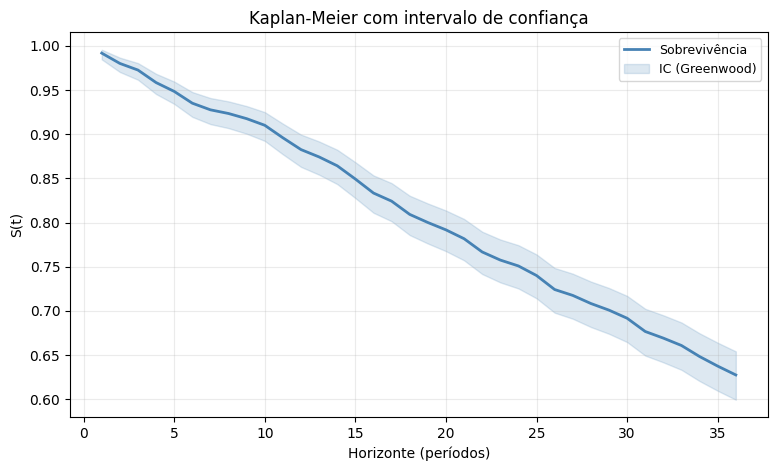

In [21]:
fig = report.plot_survival_ci(tab_km)

### 3.4 `hazard` — regressão em tempo discreto: curva **por contrato**

Expande o painel em pessoa-período e ajusta um modelo binário para "quebrou neste período,
dado que chegou vivo nele". A idade entra como *baseline* e as covariáveis deslocam essa
linha.

Duas virtudes práticas: a curva passa a ser **por contrato** (o que o ECL por contrato
exige) e covariáveis que mudam no tempo entram naturalmente — cada linha do painel é uma
observação.

In [22]:
from yggdrasil.credit_risk.ecl import DiscreteHazard

painel_feat = ContractPanel(
    painel.df.assign(feat_score=painel.df["rating"].map({"A": -1.0, "B": 0.0, "C": 1.0})),
    origin_col="safra_origem", segment_col="produto", drop_post_default=False,
)

comparacao_baseline = {}
for base in ["dummies", "spline", "linear", "log"]:
    mh = DiscreteHazard(baseline=base).fit(painel_feat, features=["feat_score"])
    c = mh.baseline_curve(horizon=48)
    comparacao_baseline[base] = {"PD 12m": c.pd_12m(), "PD lifetime": c.pd_lifetime(),
                                 "nº de termos": len(mh.coef_frame())}
pd.DataFrame(comparacao_baseline).T.round(5)

,PD 12m,PD lifetime,nº de termos
dummies,0.11106,0.45888,37.0
spline,0.10577,0.46957,9.0
linear,0.11196,0.47828,3.0
log,0.11244,0.45862,3.0


`dummies` é totalmente flexível (uma indicadora por idade) mas instável na cauda rala;
`spline` suaviza; `linear`/`log` são as formas paramétricas mais econômicas. A escolha
aparece no **número de termos** e na estabilidade da cauda.

In [23]:
mh = DiscreteHazard(baseline="spline").fit(painel_feat, features=["feat_score"])
mh.coef_frame().round(4)

,termo,coeficiente,odds_ratio
0,(intercepto),-3.6426,0.0262
1,spline_0,-0.1147,0.8916
2,spline_1,-0.8135,0.4433
3,spline_2,-1.0474,0.3508
4,spline_3,-0.3708,0.6902
5,spline_4,-0.4702,0.6249
6,spline_5,-0.5255,0.5913
7,spline_6,-0.2718,0.7620
8,feat_score,0.4921,1.6358


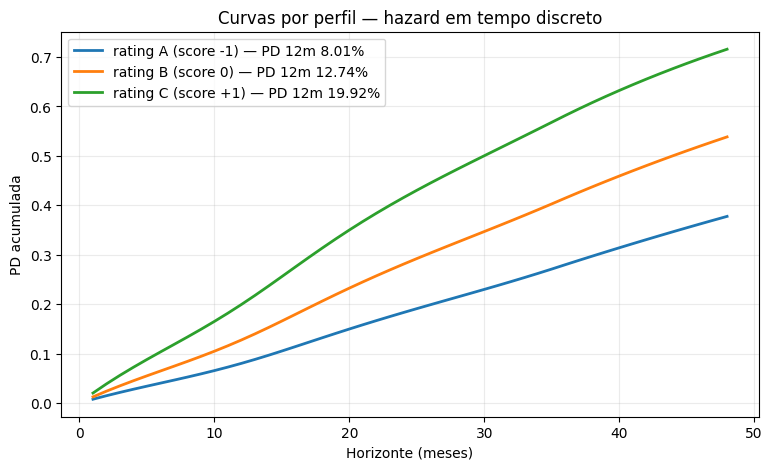

In [24]:
# A curva de cada perfil de risco — é isso que o motor entrega e os outros não.
perfis = {"rating A (score -1)": -1.0, "rating B (score 0)": 0.0, "rating C (score +1)": 1.0}
fig, ax = plt.subplots(figsize=(9, 5))
for rotulo, score in perfis.items():
    c = mh.predict_curve([score], horizon=48)
    ax.plot(c.cumulative().index, c.cumulative(), lw=2,
            label=f"{rotulo} — PD 12m {c.pd_12m():.2%}")
ax.set_xlabel("Horizonte (meses)"); ax.set_ylabel("PD acumulada")
ax.set_title("Curvas por perfil — hazard em tempo discreto"); ax.grid(alpha=.25); ax.legend()
plt.show()

> O *link* padrão é o **logit** (`scikit-learn`, núcleo do pacote). O `cloglog` — o análogo
> em tempo discreto do modelo de riscos proporcionais de Cox — está disponível via
> `DiscreteHazard(link="cloglog")` e é carregado **sob demanda**: sem o extra
> `[econometric]` instalado, o erro diz o que fazer em vez de quebrar o import.

### 3.5 `markov` — cadeia sobre a matriz de transição

Quando a carteira já tem uma **régua de rating** funcionando, estima-se a matriz de um
período e projeta-se por **Chapman-Kolmogorov**: a PD acumulada em `t` de quem está no
rating `i` é `(Mᵗ)[i, default]`.

A estimação e o z-shift já existiam em `credit_risk.capital.migration` e são chamados
daqui — **uma única fórmula de migração no repositório**.

In [25]:
from yggdrasil.credit_risk.ecl import MarkovPD

mk = MarkovPD().fit(painel, rating_col="rating")
mk.matrix_frame().round(4)

para,A,B,C,D
de,,,,
A,0.9911,0.0000,0.0000,0.0089
B,0.0000,0.9853,0.0000,0.0147
C,0.0000,0.0000,0.9767,0.0233
D,0.0000,0.0000,0.0000,1.0000


In [26]:
mk.pd_by_rating((12, 24, 36, 48)).round(4)

,rating,pd_12p,pd_24p,pd_36p,pd_48p
0,A,0.1019,0.1934,0.2756,0.3494
1,B,0.1627,0.2989,0.4130,0.5085
2,C,0.2463,0.4320,0.5719,0.6774


In [27]:
# Dois estimadores da matriz. 'duration' estima o gerador em tempo contínuo e aproveita
# melhor as migrações raras (um caminho A->B->D informa a célula A->D sem observá-la).
coorte = MarkovPD(method="cohort").fit(painel, rating_col="rating")
duracao = MarkovPD(method="duration").fit(painel, rating_col="rating")
pd.DataFrame({"cohort": coorte.pd_by_rating((12, 48)).set_index("rating").stack(),
              "duration": duracao.pd_by_rating((12, 48)).set_index("rating").stack()}).round(5)

cohort  duration
rating                          
A      pd_12p  0.10188   0.10145
       pd_48p  0.34937   0.34812
B      pd_12p  0.16269   0.16160
       pd_48p  0.50848   0.50590
C      pd_12p  0.24633   0.24384
       pd_48p  0.67736   0.67306

### 3.6 Os cinco lado a lado

A vantagem de uma fachada única: comparar os métodos no **mesmo painel** é um laço.

In [28]:
motores = {}
for metodo in ["constant", "vintage", "km"]:
    motores[metodo] = LifetimePD(method=metodo, horizon=48).fit(painel, by="produto")
motores["hazard"] = LifetimePD(method="hazard", horizon=48, baseline="spline").fit(
    painel_feat, by="produto", features=["feat_score"])

resumo = pd.concat([m.summary().assign(metodo=k) for k, m in motores.items()], ignore_index=True)
resumo[["metodo", "grupo", "pd_12m", "pd_lifetime"]].pivot(
    index="metodo", columns="grupo", values=["pd_12m", "pd_lifetime"]).round(4)

pd_12m            pd_lifetime           
grupo     cartao consignado      cartao consignado
metodo                                            
constant  0.1675     0.0690      0.5197     0.2486
hazard    0.1441     0.0652      0.6554     0.2920
km        0.1675     0.0690      0.6445     0.3186
vintage   0.1675     0.0690      0.6445     0.3186

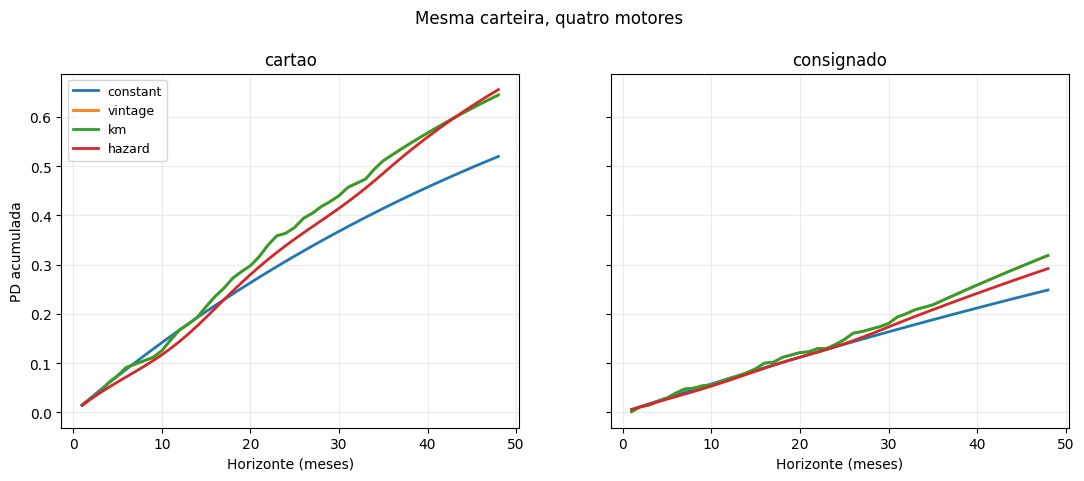

In [29]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, produto in zip(eixos, ["cartao", "consignado"]):
    for nome, m in motores.items():
        c = m.curve(produto)
        ax.plot(c.cumulative().index, c.cumulative(), lw=2, label=nome)
    ax.set_title(produto); ax.set_xlabel("Horizonte (meses)"); ax.grid(alpha=.25)
eixos[0].set_ylabel("PD acumulada"); eixos[0].legend(fontsize=9)
fig.suptitle("Mesma carteira, quatro motores", y=1.02)
plt.show()

Repare: `constant` e `vintage` **batem** na PD de 12 meses (por construção — a constante é
calibrada nela) mas divergem no *lifetime*, porque só a curva de safra enxerga a maturação.

### Qual motor usar

| situação | motor |
|---|---|
| só existe a PD de 12 meses do scorecard | `constant`, calibrado |
| há painel histórico e a maturação importa | `vintage` |
| a **incerteza** da curva vai para a documentação | `km` |
| o ECL é por contrato e há covariáveis | `hazard` |
| a carteira já tem régua de **rating** | `markov` |

Na prática, o desenho mais comum combina dois: a **forma** vem de `vintage`/`km` e o
**nível** vem do scorecard, via `calibrate_to` — que é a próxima seção.

---
## 4 · `calibrate_to` — o nível vem do modelo transversal

A curva empírica dá a **forma** da maturação; o scorecard dá o **nível** por cliente.
`calibrate_to` resolve o deslocamento `δ` no logit do *hazard* até a PD acumulada bater com
o alvo — **preservando o formato**, porque um deslocamento uniforme no logit não altera a
ordem nem as razões de chance entre horizontes.

In [30]:
lt = motores["vintage"]
alvos = {"cartao": 0.095, "consignado": 0.024}       # viriam do ModelSegmenter
lt_cal = lt.calibrate_to(alvos)

pd.DataFrame({
    "PD 12m antes": lt.summary().set_index("grupo")["pd_12m"],
    "alvo": pd.Series(alvos),
    "PD 12m depois": lt_cal.summary().set_index("grupo")["pd_12m"],
    "PD lifetime antes": lt.summary().set_index("grupo")["pd_lifetime"],
    "PD lifetime depois": lt_cal.summary().set_index("grupo")["pd_lifetime"],
}).round(5)

,PD 12m antes,alvo,PD 12m depois,PD lifetime antes,PD lifetime depois
cartao,0.16751,0.095,0.095,0.64447,0.43099
consignado,0.06897,0.024,0.024,0.31865,0.12236


In [31]:
antes, depois = lt.curve("cartao").hazard_, lt_cal.curve("cartao").hazard_
print("ordem dos hazards preservada:", np.array_equal(np.argsort(antes), np.argsort(depois)))
print("linhagem registrada:", lt_cal.curve("cartao").meta["calibracao"])

ordem dos hazards preservada: True
linhagem registrada: {'alvo': 0.095, 'horizonte': 12, 'delta': -0.6119670314108737}


In [32]:
# Também dá para calibrar a PD LIFETIME de um horizonte específico, não a de 12 meses.
alvo_3anos = lt.curve("cartao").calibrate_to(target=0.28, horizon=36)
print(f"PD lifetime em 36m: {alvo_3anos.pd_lifetime(36):.4%} (alvo 28,00%)")
print(f"a PD de 12m ficou em: {alvo_3anos.pd_12m():.4%} — consequência, não alvo")

PD lifetime em 36m: 28.0000% (alvo 28,00%)
a PD de 12m ficou em: 7.8047% — consequência, não alvo


---
## 5 · `condition` — o ciclo desloca a curva

O *forward-looking* exige a curva condicionada ao estado da economia. `condition(z, rho)`
faz isso pelo arcabouço de Vasicek, com a convenção de sinal do repositório:
**`z > 0` = ciclo benigno**.

São **dois modos**, e a diferença importa:

| `mode` | fórmula | propriedade |
|---|---|---|
| `"shift"` (padrão) | `Φ(Φ⁻¹(PD) − √ρ·z)` | **idempotente em `z = 0`** |
| `"conditional"` | `Φ((Φ⁻¹(PD) − √ρ·z)/√(1−ρ))` | lei condicional exata do fator único |

In [33]:
from yggdrasil.credit_risk.ecl import pit_from_ttc
from yggdrasil.credit_risk.capital.asrf import conditional_pd
from scipy.stats import norm

pd_ttc, rho = 0.05, 0.12
comparacao = pd.DataFrame({
    "z": [-2.0, -1.0, 0.0, 1.0, 2.0],
})
comparacao["shift"] = [pit_from_ttc(pd_ttc, rho, z) for z in comparacao["z"]]
comparacao["conditional"] = [pit_from_ttc(pd_ttc, rho, z, mode="conditional")
                             for z in comparacao["z"]]
comparacao.round(5)

,z,shift,conditional
0,-2.0,0.17054,0.15508
1,-1.0,0.09707,0.08316
2,0.0,0.05000,0.03976
3,1.0,0.02323,0.01689
4,2.0,0.00970,0.00635


Em `z = 0` o **shift devolve a própria PD** e o **conditional não** — e isso está certo: a
PD condicional à realização *mediana* do fator é maior que a PD média (para `PD < 0,5`),
porque a média é tomada sobre toda a distribuição de `Z`.

O padrão é o `shift` por dois motivos: é idempotente, e é **a mesma escolha** do
`zshift_transition_matrix` do motor de capital — sem isso, o caminho da curva e o caminho
da matriz de migração dariam números diferentes para a mesma pergunta.

O `conditional` fecha exatamente com `capital.asrf.conditional_pd` e com a inversa
`econometric.transforms.vasicek_z`. **Use-o quando o `z` vier de lá** — só assim a ida e a
volta fecham.

In [34]:
q = 0.999
print("shift é idempotente em z=0 ....:", np.isclose(pit_from_ttc(pd_ttc, rho, 0.0), pd_ttc))
print("conditional bate com o capital :",
      np.isclose(pit_from_ttc(pd_ttc, rho, -norm.ppf(q), mode="conditional"),
                 float(conditional_pd(pd_ttc, rho, q))))
print("rho=0 desliga o ciclo nos dois :",
      np.isclose(pit_from_ttc(pd_ttc, 0.0, -3.0), pd_ttc))

shift é idempotente em z=0 ....: True
conditional bate com o capital : True
rho=0 desliga o ciclo nos dois : True


In [35]:
cenarios = {
    "otimista (z=+1)": lt_cal.condition(z=+1.0, rho=0.10),
    "base (TTC)": lt_cal,
    "adverso (z=-1,5)": lt_cal.condition(z=-1.5, rho=0.10),
    "adverso c/ reversão": lt_cal.condition(z=-1.5, rho=0.10, decay=0.10),
}
pd.DataFrame({nome: {"PD 12m": m.curve("cartao").pd_12m(),
                     "PD lifetime": m.curve("cartao").pd_lifetime()}
              for nome, m in cenarios.items()}).T.round(4)

,PD 12m,PD lifetime
otimista (z=+1),0.0397,0.2109
base (TTC),0.0950,0.4310
"adverso (z=-1,5)",0.2803,0.8295
adverso c/ reversão,0.1912,0.5138


`decay` é a **reversão à média**: num horizonte *lifetime*, o choque de hoje não vale para
sempre. Com `decay=0.10`, ~65% do choque se dissipa em 10 períodos — por isso a PD de 12
meses quase não muda e a *lifetime* sobe bem menos.

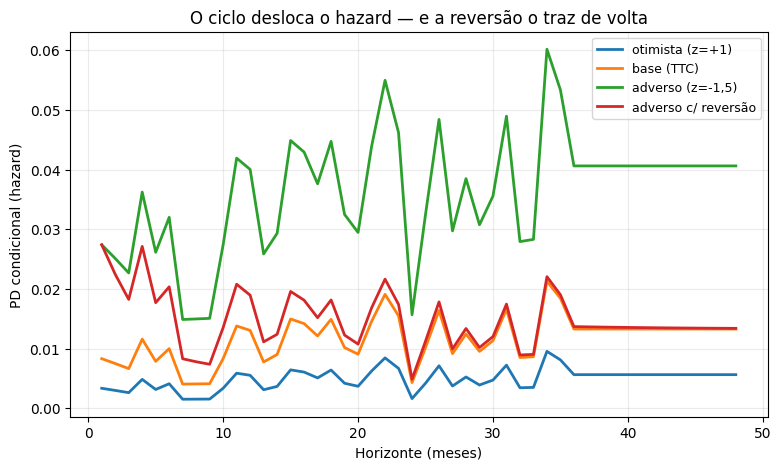

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
for nome, m in cenarios.items():
    c = m.curve("cartao")
    ax.plot(c.hazard().index, c.hazard(), lw=2, label=nome)
ax.set_xlabel("Horizonte (meses)"); ax.set_ylabel("PD condicional (hazard)")
ax.set_title("O ciclo desloca o hazard — e a reversão o traz de volta")
ax.grid(alpha=.25); ax.legend(fontsize=9)
plt.show()

In [37]:
# z pode vir como TRAJETÓRIA — é aqui que entra a projeção de um modelo satélite
# (yggdrasil.credit_risk.econometric): recessão nos 12 primeiros meses, normalizando depois.
z_projetado = np.concatenate([np.linspace(-2.0, -0.5, 12), np.zeros(36)])
com_projecao = lt_cal.condition(z_projetado, rho=0.10)
print(f"PD 12m: base {lt_cal.curve('cartao').pd_12m():.4%} -> "
      f"com projeção {com_projecao.curve('cartao').pd_12m():.4%}")
print(f"PD lifetime: base {lt_cal.curve('cartao').pd_lifetime():.4%} -> "
      f"com projeção {com_projecao.curve('cartao').pd_lifetime():.4%}")

PD 12m: base 9.5000% -> com projeção 24.6698%
PD lifetime: base 43.0992% -> com projeção 52.6370%


In [38]:
# Em method='markov' com z escalar, o condicionamento desloca a MATRIZ INTEIRA
# (todas as migrações, não só a coluna de default) — mais fiel.
mk_lt = LifetimePD(method="markov", horizon=48).fit(painel, rating_col="rating")
pd.DataFrame({
    "base": {r: mk_lt.curve(r).pd_12m() for r in ["A", "B", "C"]},
    "adverso (z=-1,5)": {r: mk_lt.condition(-1.5, rho=0.08).curve(r).pd_12m()
                         for r in ["A", "B", "C"]},
}).round(5)

,base,"adverso (z=-1,5)"
A,0.10188,0.27009
B,0.16269,0.38501
C,0.24633,0.51610


---
## 6 · Escorar a carteira

`apply` cola a estrutura a termo em cada contrato, respeitando duas coisas:

- a **idade** atual — nos motores indexados por idade (`vintage`, `km`), a curva do
  contrato começa dali, não do horizonte 1;
- o **prazo** remanescente — zera as marginais além dele: um contrato com 8 meses de prazo
  não acumula PD no 9º.

In [39]:
carteira = df.groupby("id_contrato").tail(1).copy()
carteira["idade"] = (pd.PeriodIndex(carteira["dt_ref"], freq="M").asi8
                     - pd.PeriodIndex(carteira["safra_origem"], freq="M").asi8)

escorada = lt_cal.apply(carteira, age_col="idade", term_col="prazo", detail=True)
escorada[["produto", "idade", "prazo", "pd_12m", "pd_lifetime"]].head(5).round(5)

,produto,idade,prazo,pd_12m,pd_lifetime
35,consignado,35,8,0.02834,0.02834
71,cartao,35,3,0.03932,0.03932
107,consignado,35,7,0.02484,0.02484
143,consignado,35,0,0.00000,0.00000
179,consignado,35,0,0.00000,0.00000


In [40]:
marg = [c for c in escorada.columns if c.startswith("pd_marg_h")]
print("Σ marginais == pd_lifetime ....:", np.allclose(escorada[marg].sum(axis=1),
                                                      escorada["pd_lifetime"]))
print("Σ 12 primeiras == pd_12m ......:", np.allclose(escorada[marg[:12]].sum(axis=1),
                                                      escorada["pd_12m"]))
curtos = escorada[escorada["prazo"] <= 5]
print(f"o prazo trunca ({len(curtos)} contratos com prazo <= 5):",
      np.allclose(curtos[[f"pd_marg_h{t}" for t in range(6, 49)]].to_numpy(), 0.0))

Σ marginais == pd_lifetime ....: True
Σ 12 primeiras == pd_12m ......: True
o prazo trunca (721 contratos com prazo <= 5): True


In [41]:
# Dois contratos com o MESMO produto e prazos/idades diferentes: a curva difere.
amostra = escorada[escorada["produto"] == "cartao"].nlargest(2, "prazo").head(1)
amostra = pd.concat([amostra, escorada[(escorada["produto"] == "cartao")
                                       & (escorada["prazo"].between(6, 10))].head(1)])
amostra[["idade", "prazo", "pd_12m", "pd_lifetime"]].round(5)

,idade,prazo,pd_12m,pd_lifetime
8189,0,47,0.09500,0.42333
219,35,6,0.07709,0.07709


In [42]:
# `marginal_matrix` devolve a matriz (n_contratos, horizonte) sem tocar no DataFrame —
# é o insumo direto do ecl_table.
M = lt_cal.marginal_matrix(carteira, age_col="idade", term_col="prazo")
print("matriz de PDs marginais:", M.shape)
print("uso de memória:", f"{M.nbytes / 1e6:.1f} MB")

matriz de PDs marginais: (1200, 48)
uso de memória: 0.5 MB


---
## 7 · Backtest — previsto × observado

Rodar contra o **mesmo** painel do ajuste dá acerto exato (é in-sample) e serve para
validar a mecânica; na prática o painel do backtest é a janela *out-of-time*. A coluna
`dentro_do_ic` é o veredito por horizonte, contra o IC de Greenwood do observado.

In [43]:
bt = lt.backtest(painel, horizons=(12, 24, 36))
bt.round(4)

,grupo,horizonte,n_em_risco_inicial,pd_prevista,pd_observada,ic_inf,ic_sup,erro_absoluto,erro_relativo,dentro_do_ic
0,cartao,12,591,0.1675,0.1675,0.1397,0.2001,0.0,0.0,True
1,cartao,24,591,0.3638,0.3638,0.3264,0.4040,0.0,0.0,True
2,cartao,36,591,0.5228,0.5228,0.4832,0.5636,0.0,0.0,True
3,consignado,12,609,0.0690,0.0690,0.0514,0.0922,0.0,0.0,True
4,consignado,24,609,0.1379,0.1379,0.1129,0.1679,0.0,0.0,True
5,consignado,36,609,0.2266,0.2266,0.1954,0.2620,0.0,0.0,True


In [44]:
# E o backtest ACUSA quando a curva está deslocada — que é para isso que ele existe.
deslocada = lt.calibrate_to({"cartao": 0.35, "consignado": 0.25})
deslocada.backtest(painel, horizons=(12, 24))[
    ["grupo", "horizonte", "pd_prevista", "pd_observada", "ic_inf", "ic_sup",
     "erro_relativo", "dentro_do_ic"]].round(4)

,grupo,horizonte,pd_prevista,pd_observada,ic_inf,ic_sup,erro_relativo,dentro_do_ic
0,cartao,12,0.3500,0.1675,0.1397,0.2001,1.0894,False
1,cartao,24,0.6534,0.3638,0.3264,0.4040,0.7961,False
2,consignado,12,0.2500,0.0690,0.0514,0.0922,2.6250,False
3,consignado,24,0.4496,0.1379,0.1129,0.1679,2.2593,False


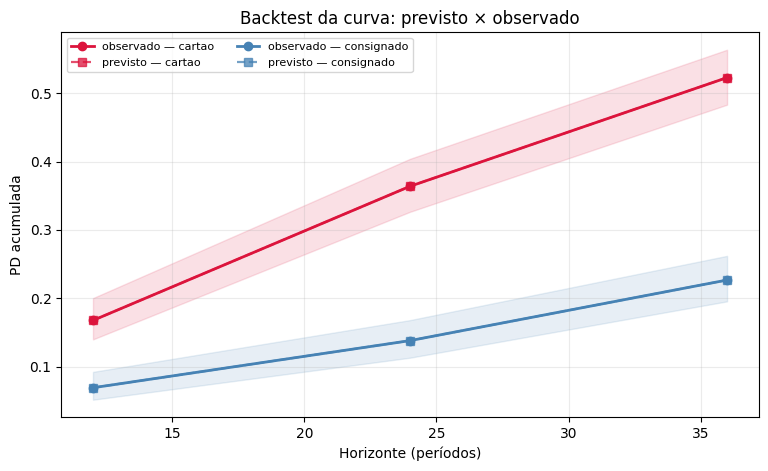

In [45]:
fig = report.plot_backtest(bt)

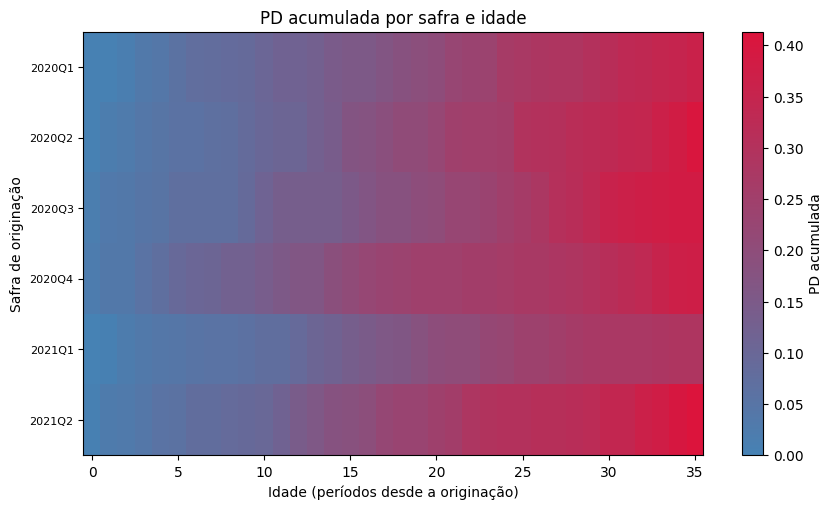

In [46]:
# O mapa de calor safra × idade separa os DOIS eixos de uma vez: maturação na horizontal,
# qualidade da originação na vertical. Um bloco de safras mais escuro na MESMA idade é
# deterioração de originação — não de ciclo.
fig = report.plot_vintage_heatmap(painel, cohort_freq="Q")

---
## 8 · Persistência e MLflow

A provisão é auditada: a auditoria precisa reconstruir o número a partir dos insumos
versionados — qual curva, qual calibração, qual cenário, qual data.

In [47]:
recarregado = LifetimePD.from_json(lt_cal.to_json())
print("curvas idênticas:", np.allclose(recarregado.curve("cartao").hazard_,
                                       lt_cal.curve("cartao").hazard_))
print("ajustes registrados:", [a["tipo"] for a in recarregado.adjustments_])

curvas idênticas: True
ajustes registrados: ['logit_shift']


In [48]:
import mlflow
from yggdrasil.credit_risk.ecl import log_lifetime_pd

mlflow.set_tracking_uri("file:./mlruns")
run_id = log_lifetime_pd(lt_cal, backtest=bt,
                         experiment="/Shared/Yggdrasil/pd_lifetime_tutorial",
                         run_name="vintage_calibrada")
print("run:", run_id)
print("artefatos: curvas (acumulada e hazard), resumo, backtest, lifetime_pd.json e figuras")

2026/08/16 14:24:59 INFO mlflow.tracking.fluent: Experiment with name '/Shared/Yggdrasil/pd_lifetime_tutorial' does not exist. Creating a new experiment.


run: 66069aabff0e4147bb92cd3715ea1bff
artefatos: curvas (acumulada e hazard), resumo, backtest, lifetime_pd.json e figuras


---
## Resumo

**O que a PD lifetime acrescenta ao scorecard:** o scorecard ordena e dá o nível de 12
meses; a curva diz **quando** o risco se materializa. Sem isso não há estágio 2, não há
SICR quantitativo e não há estresse plurianual.

**Os três erros que o módulo existe para evitar:**

1. **somar a representação errada** — o ECL soma a **marginal**; a condicional conta o
   mesmo contrato várias vezes e a acumulada conta a mesma perda repetidamente;
2. **tratar o não observado como sobrevivência** — a censura exige recontar a base em
   risco idade a idade;
3. **trocar os modos de Vasicek** — `shift` e `conditional` respondem a perguntas
   diferentes, e a diferença aparece direto no nível da provisão.

**O desenho mais comum na prática:** forma de `vintage`/`km` + nível do scorecard via
`calibrate_to` + ciclo via `condition` com `decay`.

| próximo passo | |
|---|---|
| [`14`](14_tutorial_elbe.ipynb) | **ELBE** — quando não há mais PD a estimar |
| [`15`](15_tutorial_ccf.ipynb) | **CCF/EAD** — sobre qual exposição a perda incide |
| [`12`](12_tutorial_ecl.ipynb) | os três juntos na **tabela de ECL** |